In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import TargetEncoder, LabelEncoder
from datetime import datetime
from geopy.distance import geodesic
from sklearn.cluster import KMeans

In [2]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [7]:
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

In [8]:
def haversine(lat1, lon1, lat2, lon2):
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2.0) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Radius of earth in kilometers. Use 3956 for miles. Determines return value units.
    km = 6371 * c
    return km

In [9]:
def categorize_location(city_pop):
    if city_pop > 50000:
        return 1
    elif city_pop > 10000:
        return 2
    else:
        return 3

In [10]:
# Function to compute distance between merchant and transaction locations
def calculate_distance_between_locations(lat1, long1, lat2, long2):
    return geodesic((lat1, long1), (lat2, long2)).kilometers


In [11]:
def data_processing(df_path):
    df = pd.read_csv(df_path)
    df.drop(df.columns[0], axis=1, inplace=True)
    df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
    df['dob'] = pd.to_datetime(df['dob'])
    
    df['year'] = df['trans_date_trans_time'].dt.year
    df['month'] = df['trans_date_trans_time'].dt.month
    df['day'] = df['trans_date_trans_time'].dt.day
    df['time'] = df['trans_date_trans_time'].dt.time
    
    df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')
    
    # Ensure 'dob' is in datetime format
    df['dob'] = pd.to_datetime(df['dob'])

    # Calculate age and create a new 'age' column
    df['age'] = df['dob'].apply(calculate_age)
    
    # Calculate distance and create a new 'distance_km' column
#     df['dist_client_merch'] = df.apply(lambda row: haversine(row['lat'], row['long'], row['merch_lat'], row['merch_long']), axis=1)
    # Apply the function to create a new feature
    df['distance_to_merchant'] = df.apply(
        lambda row: calculate_distance_between_locations(row['lat'], row['long'], row['merch_lat'], row['merch_long']),
        axis=1
    )
    
    df['location_type'] = df['city_pop'].apply(categorize_location)
    
    # Apply K-Means clustering
    coords = df[['lat', 'long']]
    kmeans = KMeans(n_clusters=5, random_state=0).fit(coords)
    df['location_cluster'] = kmeans.labels_
    
    le = LabelEncoder()
    df['le_gender'] = le.fit_transform(df['gender'])
    
#     te = TargetEncoder()
#     le_job = le.fit_transform(df['job'])
#     df['le_job'] = le_job
#     le_street = le.fit_transform(df['street'])
#     df['le_street'] = le_street
#     le_merchant = le.fit_transform(df['merchant'])
#     df['le_merchant'] = le_merchant
#     le_city = le.fit_transform(df['city'])
#     df['le_city'] = le_city
#     le_state = le.fit_transform(df['state'])
#     le_category = le.fit_transform(df['category'])
#     df['le_category'] = le_category
    
    return df

In [12]:
df = data_processing('../fraudTrain.csv')

In [17]:
df.dtypes

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
year                              int32
month                             int32
day                               int32


In [18]:
category_counts = df.select_dtypes(include='object').nunique()

In [19]:
category_counts

merchant         693
category          14
first            352
last             481
gender             2
street           983
city             894
state             51
job              494
trans_num    1296675
dtype: int64

In [154]:
df['job'].unique()

array(['Psychologist, counselling', 'Special educational needs teacher',
       'Nature conservation officer', 'Patent attorney',
       'Dance movement psychotherapist', 'Transport planner',
       'Arboriculturist', 'Designer, multimedia',
       'Public affairs consultant', 'Pathologist', 'IT trainer',
       'Systems developer', 'Engineer, land', 'Systems analyst',
       'Naval architect', 'Radiographer, diagnostic',
       'Programme researcher, broadcasting/film/video', 'Energy engineer',
       'Event organiser', 'Operational researcher', 'Market researcher',
       'Probation officer', 'Leisure centre manager',
       'Corporate investment banker', 'Therapist, occupational',
       'Call centre manager', 'Police officer',
       'Education officer, museum', 'Physiotherapist', 'Network engineer',
       'Forensic psychologist', 'Geochemist',
       'Armed forces training and education officer',
       'Designer, furniture', 'Optician, dispensing',
       'Psychologist, forensic

In [128]:
print(df['job'].value_counts())

job
Film/video editor             9779
Exhibition designer           9199
Naval architect               8684
Surveyor, land/geomatics      8680
Materials engineer            8270
                              ... 
Information officer              8
Veterinary surgeon               8
Ship broker                      7
Contracting civil engineer       7
Warehouse manager                7
Name: count, Length: 494, dtype: int64


In [132]:
df['city'].value_counts().tail(20)

city
Freeport         9
North East       9
Oakton           9
Clarion          9
Gaines           8
Morven           8
Noblesville      8
Las Vegas        8
Buellton         8
Crouse           8
Irvington        8
Pleasant Hill    8
Wappapello       8
Norfolk          7
Streator         7
Vacaville        7
Claypool         7
Karns City       7
Bruce            7
Chattanooga      7
Name: count, dtype: int64

In [133]:
job_categories = {
    "Psychology & Therapy": [
        'Psychologist, counselling', 'Dance movement psychotherapist',
        'Therapist, occupational', 'Forensic psychologist', 'Counsellor',
        'Child psychotherapist', 'Psychologist, forensic', 'Psychotherapist, child',
        'Psychologist, sport and exercise', 'Occupational psychologist',
        'Therapist, horticultural', 'Art therapist', 'Music therapist',
        'Therapist, drama', 'Sport and exercise psychologist',
        'Clinical psychologist', 'Counselling psychologist', 'Psychotherapist'
    ],
    "Education & Training": [
        'Special educational needs teacher', 'IT trainer', 'Teacher, English as a foreign language',
        'Teacher, secondary school', 'Teacher, early years/pre', 'English as a second language teacher',
        'Teacher, primary school', 'Teacher, adult education', 'Lecturer, higher education',
        'Lecturer, further education', 'Education administrator', 'Teaching laboratory technician',
        'Further education lecturer', 'Educational psychologist', 'Professor Emeritus',
        'Associate Professor', 'Higher education careers adviser', 'Private music teacher'
    ],
    "Engineering & Technology": [
        'Engineer, land', 'Systems developer', 'Engineer, mining', 'Electrical engineer',
        'Engineer, electronics', 'Engineer, broadcasting (operations)',
        'Engineer, biomedical', 'Engineering geologist', 'Engineer, manufacturing',
        'Engineer, technical sales', 'Engineer, structural', 'Engineer, control and instrumentation',
        'Mechanical engineer', 'Civil engineer, contracting', 'Engineer, petroleum',
        'Engineer, drilling', 'Engineer, aeronautical', 'Engineer, agricultural',
        'Engineer, civil (consulting)', 'Engineer, site', 'Engineer, civil (contracting)',
        'Engineer, materials', 'Biomedical engineer', 'Maintenance engineer',
        'Engineer, communications', 'Engineer, building services', 'Engineer, structural',
        'Engineer, control and instrumentation', 'Engineer, automotive', 'Engineer, production',
        'Engineer, technical sales'
    ],
    "Healthcare & Medicine": [
        'Radiographer, diagnostic', 'Physiotherapist', 'Paediatric nurse',
        'Clinical biochemist', 'Clinical research associate', 'Health visitor',
        'Nutritional therapist', 'Dietitian', 'Occupational therapist',
        'Physician', 'Podiatrist', 'Health promotion specialist',
        'Immunologist', 'Neurosurgeon', 'Pharmacist, hospital',
        'Psychiatric nurse', 'Community pharmacist', 'Medical physicist',
        'Paediatric nurse', 'Hospital doctor', 'Diagnostic radiographer',
        'Doctor, hospital', 'Medical technical officer', 'General practice doctor',
        'Hospital pharmacist', 'Pharmacologist', 'Surgeon', 'Therapist, sports',
        'Physician', 'Health service manager', 'Medical secretary',
        'Biochemist, clinical', 'Doctor, general practice', 'Osteopath',
        'Therapist, art', 'Chiropodist', 'Scientist, physiological'
    ],
    "Science & Research": [
        'Scientist, research (maths)', 'Research scientist (life sciences)',
        'Research scientist (physical sciences)', 'Research scientist (medical)',
        'Biomedical scientist', 'Research officer, trade union',
        'Geochemist', 'Geoscientist', 'Cytogeneticist', 'Clinical cytogeneticist',
        'Research officer, political party', 'Research officer, trade union',
        'Scientist, clinical (histocompatibility and immunogenetics)',
        'Scientist, research (medical)', 'Scientist, research (physical sciences)',
        'Research officer, political party', 'Clinical research associate',
        'Field seismologist', 'Geologist, engineering', 'Research scientist (maths)',
        'Geophysicist/field seismologist'
    ],
    "Finance & Legal": [
        'Patent attorney', 'Corporate investment banker', 'Claims inspector/assessor',
        'Insurance broker', 'Accountant, chartered public finance', 'Accountant, chartered',
        'Accountant, chartered certified', 'Accountant, chartered public finance',
        'Solicitor', 'Chartered accountant', 'Solicitor, Scotland',
        'Tax inspector', 'Investment analyst', 'Chartered legal executive (England and Wales)',
        'Financial trader', 'Chief Financial Officer', 'Chief Executive Officer',
        'Chief Operating Officer', 'Chief Strategy Officer', 'Chief Technology Officer',
        'Chief Marketing Officer', 'Chief of Staff', 'Investment banker, corporate',
        'Investment banker, operational', 'Financial adviser', 'Tax adviser',
        'Legal secretary', 'Trade mark attorney', 'Pensions consultant', 
        'Tax inspector', 'Insurance underwriter', 'Insurance claims handler'
    ],
    "Creative Arts & Design": [
        'Designer, multimedia', 'Designer, furniture', 'Designer, jewellery',
        'Designer, television/film set', 'Designer, textile',
        'Fine artist', 'Graphic designer', 'Illustrator', 'Ceramics designer',
        'Designer, ceramics/pottery', 'Special effects artist', 'Artist',
        'Designer, interior/spatial', 'Designer, exhibition/display', 
        'Textile designer', 'Designer, industrial/product', 
        'Designer, television/film set', 'Designer, ceramics/pottery',
        'Designer, furniture', 'Designer, jewellery', 'Designer, multimedia',
        'Animator', 'Architect', 'Architectural technologist', 'Architect, landscape',
        'Designer, multimedia', 'Interior and spatial designer', 'Designer, ceramics/pottery',
        'Fashion designer'
    ],
    "Business & Management": [
        'Public affairs consultant', 'Event organiser', 'Call centre manager',
        'Leisure centre manager', 'Retail merchandiser', 'Retail manager',
        'Store manager', 'Store planner', 'Project manager',
        'Production manager', 'Operations manager', 'Retail buyer', 
        'Retail banker', 'Hotel manager', 'Restaurant manager, fast food',
        'Store planner', 'Operations manager', 'Merchandiser, retail',
        'Logistics and distribution manager', 'Management consultant', 
        'Retail manager', 'Store manager', 'Facilities manager', 'Programme researcher',
        'Chief Marketing Officer', 'Chief Strategy Officer', 'Chief Financial Officer',
        'Chief Operating Officer', 'Chief Executive Officer', 'Chief of Staff',
        'Purchasing manager'
    ],
    "Communications & Media": [
        'Journalist, newspaper', 'Journalist, broadcast', 'Editor, film/video',
        'Editor, magazine features', 'Copywriter, advertising', 'Editor, commissioning',
        'Editor, magazine features', 'Copywriter, advertising', 'Commissioning editor',
        'Producer, television/film/video', 'Producer, radio', 'Television camera operator',
        'Camera operator', 'Television floor manager', 'Press photographer',
        'Television production assistant', 'Video editor', 'Media buyer',
        'Media planner', 'Radio broadcast assistant', 'Press sub', 'Film/video editor',
        'Television/film/video producer', 'Television floor manager', 'Broadcast journalist',
        'Broadcast engineer', 'Television camera operator', 'Camera operator',
        'Television production assistant', 'Radio producer', 'Radio broadcast assistant',
        'Television/film/video producer'
    ],
    "IT & Technology": [
        'Systems developer', 'Systems analyst', 'Network engineer', 'Applications developer',
        'Telecommunications researcher', 'Database administrator', 'IT consultant',
        'IT trainer', 'Information systems manager', 'Programmer, multimedia',
        'Multimedia programmer', 'Web designer', 'IT consultant', 'Systems developer',
        'Network engineer', 'Programmer, multimedia', 'Programmer, applications',
        'Database administrator', 'Web designer', 'IT consultant', 'Network engineer',
        'Information systems manager', 'IT trainer', 'Systems analyst'
    ],
    "Environmental & Conservation": [
        'Nature conservation officer', 'Arboriculturist', 'Amenity horticulturist',
        'Conservation officer, historic buildings', 'Environmental consultant',
        'Environmental education officer', 'Ecologist', 'Environmental health practitioner',
        'Environmental manager', 'Environmental consultant', 'Environmental education officer',
        'Horticulturist, commercial', 'Horticultural therapist', 'Conservator, museum/gallery',
        'Museum/gallery conservator', 'Horticulturist, commercial', 'Horticultural consultant',
        'Tree surgeon', 'Race relations officer', 'Conservation officer, historic buildings',
        'Historic buildings inspector/conservation officer', 'Horticulturist, commercial',
        'Horticultural consultant', 'Tree surgeon', 'Nature conservation officer',
        'Arboriculturist', 'Amenity horticulturist'
    ],
    "Law & Security": [
        'Police officer', 'Probation officer', 'Immigration officer',
        'Solicitor', 'Barrister', 'Claims inspector/assessor', 'Contractor',
        'Lawyer', 'Solicitor, Scotland', 'Barrister', 'Legal secretary', 
        'Insurance claims handler', 'Police officer', 'Probation officer', 
        'Immigration officer', 'Claims inspector/assessor', 'Insurance broker',
        'Insurance underwriter', 'Lawyer', 'Legal secretary', 'Prison officer', 
        'Claims inspector/assessor', 'Lawyer', 'Legal secretary', 
        'Immigration officer'
    ],
    "Science & Technology": [
        'Science writer', 'Research scientist (physical sciences)', 
        'Research scientist (life sciences)', 'Research scientist (medical)',
        'Science writer', 'Hydrogeologist', 'Physiologist', 'Marine scientist',
        'Science writer', 'Physiologist', 'Hydrogeologist', 'Clinical cytogeneticist',
        'Research scientist (medical)', 'Research scientist (physical sciences)', 
        'Research scientist (life sciences)', 'Research scientist (maths)',
        'Research scientist (physical sciences)', 'Research scientist (maths)',
        'Clinical cytogeneticist', 'Research scientist (physical sciences)',
        'Science writer', 'Hydrogeologist', 'Physiologist', 'Marine scientist',
        'Research scientist (medical)', 'Research scientist (maths)',
        'Research scientist (life sciences)'
    ],
    "Public Service & Government": [
        'Police officer', 'Civil Service administrator', 'Civil Service fast streamer',
        'Local government officer', 'Housing officer', 'Environmental health practitioner',
        'Firefighter', 'Civil Service fast streamer', 'Probation officer',
        'Social research officer, government', 'Social research officer, government',
        'Housing manager/officer', 'Civil Service administrator', 'Local government officer',
        'Civil Service fast streamer', 'Housing officer', 'Environmental health practitioner',
        'Civil Service administrator', 'Local government officer'
    ],
    "Transport & Logistics": [
        'Transport planner', 'Logistics and distribution manager', 'Air traffic controller',
        'Freight forwarder', 'Warehouse manager', 'Freight forwarder', 
        'Freight forwarder', 'Freight forwarder', 'Freight forwarder',
        'Transport planner', 'Logistics and distribution manager', 'Warehouse manager',
        'Warehouse manager', 'Transport manager', 'Logistics and distribution manager',
        'Logistics and distribution manager', 'Warehouse manager', 'Transport manager',
        'Freight forwarder', 'Freight forwarder', 'Freight forwarder',
        'Transport manager', 'Logistics and distribution manager', 'Warehouse manager',
        'Warehouse manager', 'Warehouse manager', 'Warehouse manager', 
        'Transport manager', 'Transport manager', 'Freight forwarder', 
        'Transport manager'
    ],
    "Social Services & Community Work": [
        'Community education officer', 'Community arts worker', 'Community education officer',
        'Community development worker', 'Community education officer', 
        'Community arts worker', 'Community pharmacist', 'Social worker',
        'Community development worker', 'Community development worker',
        'Community pharmacist', 'Youth worker', 'Community arts worker',
        'Community pharmacist', 'Social worker', 'Youth worker', 
        'Community development worker', 'Community arts worker', 'Community pharmacist',
        'Community pharmacist', 'Community development worker', 'Social worker', 
        'Social worker', 'Youth worker', 'Youth worker', 'Youth worker',
        'Social worker'
    ],
    "Hospitality & Tourism": [
        'Travel agency manager', 'Tourism officer', 'Hotel manager',
        'Tourist information centre manager', 'Restaurant manager, fast food',
        'Tourist information centre manager', 'Hotel manager', 'Tour manager',
        'Hotel manager', 'Tour manager', 'Travel agency manager', 
        'Travel agency manager', 'Restaurant manager, fast food',
        'Hotel manager', 'Tour manager', 'Tourism officer', 
        'Restaurant manager, fast food', 'Travel agency manager', 
        'Travel agency manager', 'Restaurant manager, fast food', 'Restaurant manager, fast food'
    ],
    "Retail & Customer Service": [
        'Retail merchandiser', 'Retail manager', 'Store manager',
        'Store planner', 'Retail merchandiser', 'Retail buyer', 
        'Retail merchandiser', 'Retail buyer', 'Store manager',
        'Store planner', 'Retail buyer', 'Retail manager', 
        'Store manager', 'Retail buyer', 'Retail merchandiser', 
        'Store planner', 'Store manager', 'Retail buyer',
        'Store manager', 'Retail merchandiser', 'Store planner',
        'Store manager', 'Store planner', 'Store manager'
    ]
}


In [214]:
reverse_dict = {job.lower().strip(): category for category, jobs in job_categories.items() for job in jobs}

# Define a function to map each job to its category
def map_job_to_category(job):
    # Convert the job to lowercase and strip whitespace before looking it up
    cleaned_job = job.lower().strip()
    return reverse_dict.get(cleaned_job, job)  # Return the original job if not found

# Apply the function to create the 'job_category' column
df['job_category'] = df['job'].apply(map_job_to_category)

In [215]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count
1169551,2020-05-03 14:45:04,60422928733,fraud_O'Connell-Ullrich,home,10.25,Jeffrey,Powers,M,38352 Parrish Road Apt. 652,North Augusta,SC,29860,33.6028,-81.9748,46944,Secondary school teacher,1942-04-02,88189431b273f0fac90265451133908d,1367592304,32.763297,-82.309972,0,2020,5,3,1900-01-01 14:45:04,82,98.214092,2,1,1,Secondary school teacher,Education & Training,Education & Training,Education & Training,65+ (Senior Citizen),1531,12


In [216]:
# # Create a reverse mapping with lowercase keys
# job_to_category = {job.lower(): category for category, jobs in job_categories.items() for job in jobs}

# # Function to map job title to category or return the job title itself
# def map_job_category(job):
#     job_lower = job.lower()
#     if job_lower in job_to_category:
#         return job_to_category[job_lower]
#     else:
#         return job  # Return the job title itself if not found in the dictionary

# # Apply the function to create the job_category column
# df['job_category'] = df['job'].apply(map_job_category)

In [217]:
df['job_category'].unique()

array(['Psychology & Therapy', 'Education & Training',
       'Environmental & Conservation', 'Finance & Legal',
       'Transport & Logistics', 'Creative Arts & Design',
       'Business & Management', 'Pathologist', 'IT & Technology',
       'Engineering & Technology', 'Naval architect',
       'Healthcare & Medicine',
       'Programme researcher, broadcasting/film/video', 'Energy engineer',
       'Operational researcher', 'Market researcher',
       'Public Service & Government', 'Education officer, museum',
       'Science & Research',
       'Armed forces training and education officer',
       'Optician, dispensing', 'Librarian, public',
       'Hospitality & Tourism', 'Human resources officer',
       'Surveyor, minerals', 'Communications & Media', 'Curator',
       'Education officer, community', 'Physicist, medical',
       'Ambulance person', 'Dealer', 'Trading standards officer',
       'Water engineer', 'Science & Technology', 'Law & Security',
       'Product/process dev

In [218]:
df['job_category'].value_counts()

job_category
Healthcare & Medicine                                    76948
Communications & Media                                   72401
Engineering & Technology                                 68145
Psychology & Therapy                                     59536
Finance & Legal                                          47409
Creative Arts & Design                                   44069
IT & Technology                                          43158
Business & Management                                    42409
Science & Research                                       42006
Education & Training                                     41145
Environmental & Conservation                             39936
Law & Security                                           33423
Public Service & Government                              17411
Science & Technology                                     15923
Hospitality & Tourism                                    10755
Exhibition designer                       

In [219]:
job_categories2 = {
    "Psychology & Therapy": [
        'Psychologist, clinical', 'Therapist, music', 'Psychiatrist','Psychology & Therapy'
    ],
    "Education & Training": [
        'Education & Training','Primary school teacher', 'Secondary school teacher', 'Early years teacher', 'Teacher, special educational needs', 'Learning mentor', 'Education officer, museum', 'Museum education officer', 'English as a foreign language teacher', 'TEFL teacher', 'Careers adviser', 'Careers information officer', 'Development worker, community', 'Education officer, community', 'Armed forces training and education officer'
    ],
    "Engineering & Technology": [
        'Engineering & Technology', 'Civil engineer', 'Mechanical engineer', 'Chemical engineer', 'Electrical engineer', 'Electronics engineer', 'Aerospace engineer', 'Aeronautical engineer', 'Structural engineer', 'Materials engineer', 'Mining engineer', 'Surveyor, land/geomatics', 'Surveyor, minerals', 'Surveyor, hydrographic', 'Surveyor, rural practice', 'Surveyor, building', 'Surveyor, commercial/residential', 'Surveyor, construction', 'Surveyor, quantity', 'Surveyor, town planner', 'Surveyor, property', 'Building control surveyor', 'Building services engineer', 'Construction engineer', 'Contracts engineer', 'Electrical engineer', 'Electronics engineer', 'Energy engineer', 'Environmental engineer', 'Manufacturing engineer', 'Mining engineer', 'Structural engineer', 'Technical brewer', 'Water engineer'
    ],
    "Healthcare & Medicine": [
        'Healthcare & Medicine', 'Doctor', 'Physician', 'Surgeon', 'Nurse, mental health', "Nurse, children's", 'Paramedic', 'Ambulance person', 'Optician, dispensing', 'Optometrist', 'Pharmacist, community', 'Medical sales representative', 'Audiological scientist', 'Physiological scientist', 'Psychiatrist', 'Veterinary surgeon', 'Radiographer, therapeutic', 'Health physicist', 'Exercise physiologist', 'Scientist, biomedical', 'Scientist, marine', 'Biomedical scientist', 'Embryologist, clinical', 'Homeopath', 'Acupuncturist', 'Herbalist', 'Occupational hygienist', 'Dispensing optician'
    ],
    "Science & Research": [
        'Science & Research', 'Research scientist', 'Clinical scientist', 'Data scientist', 'Geoscientist', 'Physicist, medical', 'Biotechnologist', 'Microbiologist', 'Marine scientist', 'Biomedical scientist', 'Embryologist, clinical', 'Hydrologist', 'Environmental scientist', 'Plant scientist', 'Materials scientist', 'Toxicologist', 'Analytical chemist', 'Biostatistician', 'Biotechnologist', 'Oceanographer', 'Agricultural consultant', 'Marine scientist', 'Biomedical scientist', 'Embryologist, clinical', 'Microbiologist'
    ],
    "Finance & Legal": [
        'Finance & Legal', 'Senior tax professional/tax inspector', 'Economist', 'Pension scheme manager', 'Chartered loss adjuster', 'Loss adjuster, chartered', 'Risk analyst', 'Chartered public finance accountant', 'Insurance risk surveyor', 'Licensed conveyancer', 'Barrister\'s clerk', 'Comptroller', 'Tax inspector', 'Chartered loss adjuster'
    ],
    "Creative Arts & Design": [
        'Creative Arts & Design', 'Art gallery manager', 'Stage manager', 'Set designer', 'Theatre manager', 'Theatre director', 'Jewellery designer', 'Furniture designer', 'Exhibition designer', 'Broadcast presenter', 'Presenter, broadcasting', 'Magazine journalist', 'Advertising copywriter', 'Musician', 'Dancer', 'Glass blower/designer', 'Theme park manager', 'Film/video production manager', 'Production assistant, television', 'Production assistant, radio', 'Location manager', 'Magazine features editor', 'Oncologist'
    ],
    "Business & Management": [
        'Business & Management', 'Company secretary', 'Operations geologist', 'Product/process development scientist', 'Product designer', 'Product manager', 'Sales promotion account executive', 'Sales executive', 'Sales professional, IT', 'Human resources officer', 'Personnel officer', 'Senior tax professional/tax inspector', 'Accountant', 'Accounting technician', 'Risk analyst', 'Pension scheme manager', 'Management consultant', 'Operations manager', 'Procurement manager', 'Chartered loss adjuster', 'Loss adjuster, chartered', 'Industrial buyer', 'Buyer, industrial', 'Buyer, retail', 'Sales professional, IT', 'Sales promotion account executive', 'Chartered public finance accountant', 'Comptroller', 'Project manager', 'Administrator', 'Administrator, education', 'Administrator, local government', 'Administrator, charities/voluntary organisations', 'Administrator, arts', 'Estate manager/land agent', 'Public house manager', 'Catering manager', 'Operations geologist'
    ],
    "Communications & Media": [
        'Communications & Media', 'Broadcast presenter', 'Television production assistant', 'Radio production assistant', 'Magazine journalist', 'Copywriter', 'Advertising copywriter', 'Public relations officer', 'Public relations account executive', 'Market researcher', 'Magazine features editor', 'Magazine journalist', 'Production assistant, television', 'Production assistant, radio', 'Magazine features editor'
    ],
    "IT & Technology": [
        'IT & Technology', 'IT consultant', 'IT manager', 'Software developer', 'Software engineer', 'Web developer', 'Web designer', 'Network engineer', 'Systems analyst', 'Data scientist', 'Cybersecurity analyst', 'Technical support engineer', 'Information officer', 'Digital marketer', 'SEO specialist', 'Content manager', 'Cloud computing engineer'
    ],
    "Environmental & Conservation": [
        'Environmental & Conservation', 'Warden/ranger', 'Fisheries officer', 'Forest/woodland manager', 'Soil scientist', 'Hydrologist', 'Hydrographic surveyor', 'Water quality scientist', 'Energy engineer', 'Energy manager'
    ],
    "Law & Security": [
        'Law & Security', 'Legal officer', 'Security officer', 'Police officer', 'Firefighter', 'Barrister', 'Solicitor', 'Legal executive', 'Chartered loss adjuster', 'Loss adjuster, chartered', 'Trading standards officer', 'Tax inspector', 'Insurance risk surveyor', 'Risk analyst', 'Legal officer'
    ],
    "Science & Technology": [
        'Science & Technology', 'Industrial/product designer', 'Metallurgist', 'Physicist, medical', 'Clinical scientist', 'Research scientist', 'Geoscientist', 'Marine scientist', 'Biomedical scientist', 'Audiological scientist', 'Scientist, marine', 'Biomedical scientist', 'Embryologist, clinical', 'Microbiologist', 'Hydrologist', 'Data scientist', 'Information officer', 'Research scientist', 'Industrial/product designer', 'Microbiologist', 'Clinical scientist', 'Biotechnologist', 'Operations geologist'
    ],
    "Public Service & Government": [
        'Public Service & Government', 'Armed forces training and education officer', 'Armed forces logistics/support/administrative officer', 'Trading standards officer', 'Public relations officer', 'Public relations account executive', 'Risk analyst', 'Regulatory affairs officer', 'Health and safety adviser', 'Regulatory affairs officer', 'Equality and diversity officer', 'Volunteer coordinator', 'Charity officer', 'Charity fundraiser', 'Aid worker', 'Emergency planning/management officer'
    ],
    "Transport & Logistics": [
        'Transport & Logistics', 'Pilot, airline', 'Airline pilot', 'Operations geologist', 'Drilling engineer', 'Mudlogger', 'Logistics officer', 'Logistics/support/administrative officer', 'Ship broker', 'Cabin crew', 'Air cabin crew', 'Air broker', 'Marine scientist', 'Naval architect', 'Geologist, wellsite', 'Seismic interpreter'
    ],
    "Social Services & Community Work": [
        'Social Services & Community Work', 'Social worker', 'Counsellor', 'Charity officer', 'Charity fundraiser', 'Development worker, community', 'Volunteer coordinator', 'Careers adviser', 'Careers information officer', 'Community worker', 'Youth worker', 'Housing officer', 'Community development officer', 'Equal opportunities officer', 'Community education officer', 'Social researcher', 'Development worker, international aid'
    ],
    "Hospitality & Tourism": [
        'Hospitality & Tourism', 'Hotel manager', 'Catering manager', 'Public house manager', 'Tour guide', 'Travel agent', 'Tour operator', 'Barista', 'Hotel receptionist', 'Tourism officer'
    ],
    "Retail & Customer Service": [
        'Retail & Customer Service', 'Retail manager', 'Retail buyer', 'Retail merchandiser', 'Sales assistant', 'Customer service manager', 'Customer service adviser', 'Sales assistant', 'Sales executive', 'Retail buyer', 'Retail merchandiser'
    ]
}


In [220]:
reverse_dict = {job.lower().strip(): category for category, jobs in job_categories2.items() for job in jobs}

# Define a function to map each job to its category
def map_job_to_category(job):
    # Convert the job to lowercase and strip whitespace before looking it up
    cleaned_job = job.lower().strip()
    return reverse_dict.get(cleaned_job, job)  # Return the original job if not found

# Apply the function to create the 'job_category' column
df['job_category2'] = df['job_category'].apply(map_job_to_category)

In [221]:
df['job_category2'].unique()

array(['Psychology & Therapy', 'Education & Training',
       'Environmental & Conservation', 'Finance & Legal',
       'Transport & Logistics', 'Creative Arts & Design',
       'Business & Management', 'Pathologist', 'IT & Technology',
       'Engineering & Technology', 'Healthcare & Medicine',
       'Programme researcher, broadcasting/film/video',
       'Operational researcher', 'Communications & Media',
       'Public Service & Government', 'Science & Research',
       'Librarian, public', 'Hospitality & Tourism', 'Curator',
       'Science & Technology', 'Dealer', 'Law & Security',
       'Social Services & Community Work',
       'Exhibitions officer, museum/gallery', 'Interpreter',
       'Scientist, audiological', 'Retail & Customer Service',
       'Waste management officer', 'Land/geomatics surveyor',
       'Commercial/residential surveyor',
       'Training and development officer', 'Cartographer',
       'Museum/gallery exhibitions officer',
       'Advertising account ex

In [222]:
job_categories3 = {
    "Psychology & Therapy": [],
    "Education & Training": [
        'Music tutor', 
        'Training and development officer', 
        'Learning disability nurse'
    ],
    "Environmental & Conservation": [
        'Waste management officer', 
        'Heritage manager'
    ],
    "Finance & Legal": [
        'Futures trader', 
        'Equities trader'
    ],
    "Transport & Logistics": [
        'Land/geomatics surveyor', 
        'Wellsite geologist', 
        'Minerals surveyor'
    ],
    "Creative Arts & Design": [
        'Curator', 
        'Gaffer', 
        'Colour technologist', 
        'Arts development officer', 
        'Furniture conservator/restorer', 
        'Visual merchandiser', 
        'Landscape architect', 
        'Conservator, furniture'
    ],
    "Business & Management": [
        'Business & Management', 
        'Secretary/administrator', 
        'Farm manager', 
        'Fitness centre manager', 
        'Sports administrator', 
        'Operations manager', 
        'Armed forces technical officer'
    ],
    "IT & Technology": [
        'IT & Technology', 
        'Communications engineer'
    ],
    "Engineering & Technology": [
        'Control and instrumentation engineer', 
        'Production engineer', 
        'Engineer, maintenance', 
        'Manufacturing systems engineer', 
        'Petroleum engineer', 
        'Contracting civil engineer'
    ],
    "Healthcare & Medicine": [
        'Mental health nurse', 
        'Orthoptist'
    ],
    "Communications & Media": [
        'Programme researcher, broadcasting/film/video', 
        'Copy', 
        'Advertising account executive', 
        'Advertising account planner'
    ],
    "Public Service & Government": [
        "Politician's assistant", 
        'Intelligence analyst', 
        'Advice worker'
    ],
    "Science & Research": [
        'Scientist, audiological', 
        'Animal technologist', 
        'Geneticist, molecular', 
        'Plant breeder/geneticist', 
        'Herpetologist', 
        'Field trials officer'
    ],
    "Science & Technology": [
        'Scientific laboratory technician', 
        'Statistician', 
        'Chemist, analytical', 
        'Operational researcher'
    ],
    "Law & Security": [],
    "Social Services & Community Work": [],
    "Hospitality & Tourism": [],
    "Retail & Customer Service": [
        'Bookseller'
    ],
    "Other/Uncategorized": [
        'Pathologist', 
        'Librarian, public', 
        'Dealer', 
        'Archivist', 
        'Phytotherapist', 
        'Lexicographer', 
        'Commercial horticulturist', 
        'Building surveyor', 
        'Quantity surveyor', 
        'Archaeologist', 
        'Sub', 
        'Make', 
        'Writer', 
        'Arts development officer', 
        'Secretary/administrator', 
        'Site engineer', 
        'Public librarian', 
        'Town planner', 
        'Outdoor activities/education manager', 
        'Academic librarian', 
        'Quarry manager', 
        'Garment/textile technologist', 
        'Sports development officer'
    ]
}


In [223]:
reverse_dict = {job.lower().strip(): category for category, jobs in job_categories3.items() for job in jobs}

# Define a function to map each job to its category
def map_job_to_category(job):
    # Convert the job to lowercase and strip whitespace before looking it up
    cleaned_job = job.lower().strip()
    return reverse_dict.get(cleaned_job, job)  # Return the original job if not found

# Apply the function to create the 'job_category' column
df['job_category3'] = df['job_category2'].apply(map_job_to_category)

In [224]:
df['job_category3'].unique()

array(['Psychology & Therapy', 'Education & Training',
       'Environmental & Conservation', 'Finance & Legal',
       'Transport & Logistics', 'Creative Arts & Design',
       'Business & Management', 'Other/Uncategorized', 'IT & Technology',
       'Engineering & Technology', 'Healthcare & Medicine',
       'Communications & Media', 'Science & Technology',
       'Public Service & Government', 'Science & Research',
       'Hospitality & Tourism', 'Law & Security',
       'Social Services & Community Work',
       'Exhibitions officer, museum/gallery', 'Interpreter',
       'Retail & Customer Service', 'Commercial/residential surveyor',
       'Cartographer', 'Museum/gallery exhibitions officer',
       'Librarian, academic', 'Land', 'Surveyor, mining',
       'Clothing/textile technologist', 'Records manager',
       'Marketing executive', 'Planning and development surveyor',
       'Animal nutritionist', 'Rural practice surveyor'], dtype=object)

In [225]:
job_categories4 = {
    "Psychology & Therapy": [],
    "Education & Training": [
        'Librarian, academic'
    ],
    "Environmental & Conservation": [
        'Land'
    ],
    "Finance & Legal": [],
    "Transport & Logistics": [],
    "Creative Arts & Design": [
        'Exhibitions officer, museum/gallery', 
        'Museum/gallery exhibitions officer', 
        'Cartographer'
    ],
    "Business & Management": [
        'Marketing executive', 
        'Records manager'
    ],
    "IT & Technology": [],
    "Engineering & Technology": [
        'Surveyor, mining', 
        'Commercial/residential surveyor', 
        'Rural practice surveyor', 
        'Planning and development surveyor'
    ],
    "Healthcare & Medicine": [
        'Animal nutritionist'
    ],
    "Communications & Media": [],
    "Science & Technology": [],
    "Public Service & Government": [],
    "Science & Research": [],
    "Hospitality & Tourism": [],
    "Law & Security": [],
    "Social Services & Community Work": [],
    "Retail & Customer Service": [],
    "Other/Uncategorized": [
        'Clothing/textile technologist', 
        'Interpreter'
    ]
}


In [226]:
reverse_dict = {job.lower().strip(): category for category, jobs in job_categories4.items() for job in jobs}

# Define a function to map each job to its category
def map_job_to_category(job):
    # Convert the job to lowercase and strip whitespace before looking it up
    cleaned_job = job.lower().strip()
    return reverse_dict.get(cleaned_job, job)  # Return the original job if not found

# Apply the function to create the 'job_category' column
df['job_category4'] = df['job_category3'].apply(map_job_to_category)

In [227]:
df['job_category4'].value_counts()

job_category4
Engineering & Technology            148939
Healthcare & Medicine               136517
Business & Management               107613
Creative Arts & Design               99910
Communications & Media               98723
Other/Uncategorized                  80019
Education & Training                 78036
Science & Research                   68713
Environmental & Conservation         67989
Psychology & Therapy                 62637
Finance & Legal                      60263
Public Service & Government          52205
Science & Technology                 47734
Transport & Logistics                47247
IT & Technology                      45204
Law & Security                       43175
Social Services & Community Work     26036
Hospitality & Tourism                14883
Retail & Customer Service            10832
Name: count, dtype: int64

In [230]:
df.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,UT,84735,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,2020,6,21,1900-01-01 12:12:08,62,119.696415,3,0,1,Science & Research,Science & Research,Science & Research,Science & Research,55-64 (Early Senior Adulthood),1513,9
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,MD,21790,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,2020,6,21,1900-01-01 12:12:19,44,75.202184,3,4,1,"Production assistant, television",Communications & Media,Communications & Media,Communications & Media,35-44 (Mid Adulthood),531,8
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,NM,88325,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,2020,6,21,1900-01-01 12:12:32,56,98.987927,3,3,1,Naval architect,Transport & Logistics,Transport & Logistics,Transport & Logistics,55-64 (Early Senior Adulthood),2070,11
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,SD,57756,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,2020,6,21,1900-01-01 12:13:36,43,84.688356,3,3,1,Volunteer coordinator,Social Services & Community Work,Social Services & Community Work,Social Services & Community Work,35-44 (Mid Adulthood),2024,8
1296674,2020-06-21 12:13:37,4292902571056973207,"fraud_Langosh, Wintheiser and Hyatt",food_dining,4.30,Jeffrey,Smith,M,135 Joseph Mountains,Sula,MT,59871,45.8433,-113.8748,218,"Therapist, horticultural",1995-08-16,8f7c8e4ab7f25875d753b422917c98c9,1371816817,46.565983,-114.186110,0,2020,6,21,1900-01-01 12:13:37,28,83.845902,3,0,1,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,25-34 (Early Adulthood),1512,8


In [199]:
# Define the bins and the corresponding labels
bins = [0, 18, 25, 35, 45, 55, 65, 120]
labels = ['<18 (Minor)', '18-24 (Young Adult)', '25-34 (Early Adulthood)', 
          '35-44 (Mid Adulthood)', '45-54 (Late Adulthood)', 
          '55-64 (Early Senior Adulthood)', '65+ (Senior Citizen)']

# Add the age group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

In [201]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group
753270,2019-11-18 05:31:14,6597888193422452,fraud_Heidenreich PLC,grocery_pos,131.38,Bill,Lane,M,4725 Hurst Curve Apt. 634,Holliday,TX,76366,33.6751,-98.6576,2317,Chief Technology Officer,1964-08-23,e780658f6a689a072d98d63979509aa5,1353216674,33.530224,-99.080349,0,2019,11,18,1900-01-01 05:31:14,59,42.399393,3,3,1,Finance & Legal,Finance & Legal,Finance & Legal,Finance & Legal,55-64 (Early Senior Adulthood)


In [208]:
df['age_group'].value_counts()

age_group
45-54 (Late Adulthood)            307711
35-44 (Mid Adulthood)             289740
65+ (Senior Citizen)              270134
25-34 (Early Adulthood)           209440
55-64 (Early Senior Adulthood)    181906
18-24 (Young Adult)                37744
<18 (Minor)                            0
Name: count, dtype: int64

In [209]:
df['cc_num_frequency'] = df.groupby('cc_num')['cc_num'].transform('count')

In [211]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency
812228,2019-12-07 12:51:49,630424987505,fraud_Schulist Ltd,food_dining,2.73,Jennifer,Black,F,2870 Bean Terrace Apt. 756,Thomas,WV,26292,39.1505,-79.503,836,Forensic psychologist,1981-08-29,1a526d147977b1fac6db0f1c1841af9a,1354884709,39.640792,-79.810483,0,2019,12,7,1900-01-01 12:51:49,42,60.535818,3,4,0,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,35-44 (Mid Adulthood),3099


In [212]:
df['fraud_transaction_count'] = df.groupby('cc_num')['is_fraud'].transform('sum')

In [213]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count
662751,2019-10-09 12:53:08,30518206766474,"fraud_Ruecker, Beer and Collier",shopping_net,5.16,Tamara,Martinez,F,471 Marquez Prairie Suite 680,Matthews,MO,63867,36.7154,-89.6287,1019,Aeronautical engineer,1979-01-26,40e3e91d50aa7f9c1122d25e87cc6992,1349787188,37.71001,-90.121846,0,2019,10,9,1900-01-01 12:53:08,45,118.745362,3,2,0,Aeronautical engineer,Engineering & Technology,Engineering & Technology,Engineering & Technology,45-54 (Late Adulthood),1519,14


In [174]:
pd.set_option("display.max_rows", None)

In [207]:
len(df['job_category4'].unique())

19

In [231]:
df.isna().sum()

trans_date_trans_time      0
cc_num                     0
merchant                   0
category                   0
amt                        0
first                      0
last                       0
gender                     0
street                     0
city                       0
state                      0
zip                        0
lat                        0
long                       0
city_pop                   0
job                        0
dob                        0
trans_num                  0
unix_time                  0
merch_lat                  0
merch_long                 0
is_fraud                   0
year                       0
month                      0
day                        0
time                       0
age                        0
distance_to_merchant       0
location_type              0
location_cluster           0
le_gender                  0
job_category               0
job_category2              0
job_category3              0
job_category4 

In [3]:
# df = pd.read_csv('../fraudTrain.csv')

In [15]:
from category_encoders.cat_boost import CatBoostEncoder

In [30]:
cbe_encoder = CatBoostEncoder()

In [234]:
categorical_col = ['merchant', 'street', 'city', 'state']
train_cbe = cbe_encoder.fit_transform(df[categorical_col], df['is_fraud'])

In [235]:
train_cbe.head()

,merchant,street,city,state
0,0.005789,0.005789,0.005789,0.005789
1,0.005789,0.005789,0.005789,0.005789
2,0.005789,0.005789,0.005789,0.005789
3,0.005789,0.005789,0.005789,0.005789
4,0.005789,0.005789,0.005789,0.005789


In [236]:
train_cbe.columns = ['cbe_' + col for col in categorical_col]


In [237]:
train_cbe.sample()

,cbe_merchant,cbe_street,cbe_city,cbe_state
804588,0.00089,0.000003,0.000002,0.004305


In [238]:
df_cbe = pd.concat([df, train_cbe], axis=1)


In [239]:
df_cbe.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_street,cbe_city,cbe_state
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,1900-01-01 00:00:18,36,78.773821,3,1,0,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,35-44 (Mid Adulthood),2028,0,0.005789,0.005789,0.005789,0.005789
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,1900-01-01 00:00:44,46,30.216618,3,0,0,Education & Training,Education & Training,Education & Training,Education & Training,45-54 (Late Adulthood),3030,0,0.005789,0.005789,0.005789,0.005789
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,1900-01-01 00:00:51,62,108.102912,3,0,1,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,55-64 (Early Senior Adulthood),503,0,0.005789,0.005789,0.005789,0.005789
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,1900-01-01 00:01:16,57,95.685115,3,0,1,Finance & Legal,Finance & Legal,Finance & Legal,Finance & Legal,55-64 (Early Senior Adulthood),493,15,0.005789,0.005789,0.005789,0.005789
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,2019,1,1,1900-01-01 00:03:06,38,77.702395,3,4,1,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,35-44 (Mid Adulthood),2017,0,0.005789,0.005789,0.005789,0.005789


In [240]:
from sklearn.preprocessing import OneHotEncoder

In [242]:
encoder = OneHotEncoder(drop='first')

In [255]:
# Columns to one-hot encode
columns_to_encode = ['category', 'age_group', 'job_category4']

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(df_cbe[columns_to_encode])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
# one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(columns_to_encode))

In [256]:
feature_names = encoder.get_feature_names_out()

In [258]:
feature_names

array(['category_food_dining', 'category_gas_transport',
       'category_grocery_net', 'category_grocery_pos',
       'category_health_fitness', 'category_home', 'category_kids_pets',
       'category_misc_net', 'category_misc_pos', 'category_personal_care',
       'category_shopping_net', 'category_shopping_pos',
       'category_travel', 'age_group_25-34 (Early Adulthood)',
       'age_group_35-44 (Mid Adulthood)',
       'age_group_45-54 (Late Adulthood)',
       'age_group_55-64 (Early Senior Adulthood)',
       'age_group_65+ (Senior Citizen)',
       'job_category4_Communications & Media',
       'job_category4_Creative Arts & Design',
       'job_category4_Education & Training',
       'job_category4_Engineering & Technology',
       'job_category4_Environmental & Conservation',
       'job_category4_Finance & Legal',
       'job_category4_Healthcare & Medicine',
       'job_category4_Hospitality & Tourism',
       'job_category4_IT & Technology', 'job_category4_Law & Security'

In [273]:
print(one_hot_encoded.shape)
print(len(feature_names))


(1296675, 36)
36


In [264]:
one_hot_encoded.shape

(1296675, 36)

In [275]:
one_hot_encoded_df = pd.DataFrame.sparse.from_spmatrix(one_hot_encoded)
one_hot_encoded_df.columns = feature_names

In [276]:
one_hot_encoded_df.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category4_Communications & Media,job_category4_Creative Arts & Design,job_category4_Education & Training,job_category4_Engineering & Technology,job_category4_Environmental & Conservation,job_category4_Finance & Legal,job_category4_Healthcare & Medicine,job_category4_Hospitality & Tourism,job_category4_IT & Technology,job_category4_Law & Security,job_category4_Other/Uncategorized,job_category4_Psychology & Therapy,job_category4_Public Service & Government,job_category4_Retail & Customer Service,job_category4_Science & Research,job_category4_Science & Technology,job_category4_Social Services & Community Work,job_category4_Transport & Logistics
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [277]:
df_combined = pd.concat([one_hot_encoded_df, df_cbe], axis=1)

In [279]:
df_combined.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category4_Communications & Media,job_category4_Creative Arts & Design,job_category4_Education & Training,job_category4_Engineering & Technology,job_category4_Environmental & Conservation,job_category4_Finance & Legal,job_category4_Healthcare & Medicine,job_category4_Hospitality & Tourism,job_category4_IT & Technology,job_category4_Law & Security,job_category4_Other/Uncategorized,job_category4_Psychology & Therapy,job_category4_Public Service & Government,job_category4_Retail & Customer Service,job_category4_Science & Research,job_category4_Science & Technology,job_category4_Social Services & Community Work,job_category4_Transport & Logistics,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_street,cbe_city,cbe_state
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,1900-01-01 00:00:18,36,78.773821,3,1,0,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,35-44 (Mid Adulthood),2028,0,0.005789,0.005789,0.005789,0.005789
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,1900-01-01 00:00:44,46,30.216618,3,0,0,Education & Training,Education & Training,Education & Training,Education & Training,45-54 (Late Adulthood),3030,0,0.005789,0.005789,0.005789,0.005789
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,1900-01-01 00:00:51,62,108.102912,3,0,1,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,55-64 (Early Senior Adulthood),503,0,0.005789,0.005789,0.005789,0.005789
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,1900-01-01 00:01:16,57,95.685115,3,0,1,Finance & Legal,Finance & Legal,Finance & Legal,Finance & Legal,55-64 (Early Senior Adulthood),493,15,0.005789,0.005789,0.005789,0.005789
4,0.0,0.0,0.0,0.0,0

In [265]:
print(one_hot_encoded[:5])

  (0, 7)	1.0
  (0, 14)	1.0
  (0, 29)	1.0
  (1, 3)	1.0
  (1, 15)	1.0
  (1, 20)	1.0
  (2, 16)	1.0
  (2, 22)	1.0
  (3, 1)	1.0
  (3, 16)	1.0
  (3, 23)	1.0
  (4, 8)	1.0
  (4, 14)	1.0
  (4, 29)	1.0


In [285]:
from sklearn.preprocessing import StandardScaler

In [286]:
z_score_scaler = StandardScaler()

In [287]:
df_combined['amt_z_score'] = z_score_scaler.fit_transform(df[['amt']])
df_combined['city_pop_z_score'] = z_score_scaler.fit_transform(df[['city_pop']])

In [288]:
df_combined.head()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category4_Communications & Media,job_category4_Creative Arts & Design,job_category4_Education & Training,job_category4_Engineering & Technology,job_category4_Environmental & Conservation,job_category4_Finance & Legal,job_category4_Healthcare & Medicine,job_category4_Hospitality & Tourism,job_category4_IT & Technology,job_category4_Law & Security,job_category4_Other/Uncategorized,job_category4_Psychology & Therapy,job_category4_Public Service & Government,job_category4_Retail & Customer Service,job_category4_Science & Research,job_category4_Science & Technology,job_category4_Social Services & Community Work,job_category4_Transport & Logistics,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,job_category,job_category2,job_category3,job_category4,age_group,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_street,cbe_city,cbe_state,amt_z_score,city_pop_z_score
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,2019,1,1,1900-01-01 00:00:18,36,78.773821,3,1,0,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,Psychology & Therapy,35-44 (Mid Adulthood),2028,0,0.005789,0.005789,0.005789,0.005789,-0.407826,-0.282589
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,2019,1,1,1900-01-01 00:00:44,46,30.216618,3,0,0,Education & Training,Education & Training,Education & Training,Education & Training,45-54 (Late Adulthood),3030,0,0.005789,0.005789,0.005789,0.005789,0.230039,-0.293670
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,2019,1,1,1900-01-01 00:00:51,62,108.102912,3,0,1,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,Environmental & Conservation,55-64 (Early Senior Adulthood),503,0,0.005789,0.005789,0.005789,0.005789,0.934149,-0.280406
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,2019,1,1,1900-01-01 00:01:16,57,95.685115,3,0,1,Finance & Legal,Finance & Legal,Finance & Legal,Finance & Legal,55-64 

In [245]:
encoded_features

<1296675x36 sparse matrix of type '<class 'numpy.float64'>'
	with 3650654 stored elements in Compressed Sparse Row format>

In [291]:
columns_to_drop = [
    'merchant', 'category', 'gender', 'street', 'city', 'state', 'cbe_street', 'job', 'first', 'last', 'time', 'cc_num', 'year', 'trans_date_trans_time', 'trans_num','dob','distance_to_merchant','job_category', 'job_category2', 'job_category3','job_category4', 'age_group', 'amt', 'city_pop'
]

# Create a new DataFrame by dropping the specified columns
df_1 = df_combined.drop(columns=columns_to_drop)



In [292]:
df_1.sample()

,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,age_group_25-34 (Early Adulthood),age_group_35-44 (Mid Adulthood),age_group_45-54 (Late Adulthood),age_group_55-64 (Early Senior Adulthood),age_group_65+ (Senior Citizen),job_category4_Communications & Media,job_category4_Creative Arts & Design,job_category4_Education & Training,job_category4_Engineering & Technology,job_category4_Environmental & Conservation,job_category4_Finance & Legal,job_category4_Healthcare & Medicine,job_category4_Hospitality & Tourism,job_category4_IT & Technology,job_category4_Law & Security,job_category4_Other/Uncategorized,job_category4_Psychology & Therapy,job_category4_Public Service & Government,job_category4_Retail & Customer Service,job_category4_Science & Research,job_category4_Science & Technology,job_category4_Social Services & Community Work,job_category4_Transport & Logistics,zip,lat,long,unix_time,merch_lat,merch_long,is_fraud,month,day,age,location_type,location_cluster,le_gender,cc_num_frequency,fraud_transaction_count,cbe_merchant,cbe_city,cbe_state,amt_z_score,city_pop_z_score
1011206,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27522,36.1124,-78.6476,1361396358,36.10189,-78.281456,0,2,20,36,2,4,0,2071,0,0.015866,0.000004,0.004958,-0.425479,-0.253313


In [43]:
df_test = data_processing('../fraudTest.csv')

In [44]:
cbe_encoder = CatBoostEncoder()
test_cbe = cbe_encoder.fit_transform(df_test[categorical_col], df_test['is_fraud'])
test_cbe.columns = ['cbe_' + col for col in categorical_col]
df_cbe_test = pd.concat([df_test, test_cbe], axis=1)

In [45]:
df_cbe_test.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,distance_to_merchant,location_type,location_cluster,le_gender,cbe_merchant,cbe_category,cbe_street,cbe_city,cbe_state,cbe_job
497369,2020-12-19 09:57:24,4979422371139333,"fraud_Kutch, Hermiston and Farrell",gas_transport,75.3,Kelly,Zimmerman,F,1893 Katie Tunnel,Westerville,NE,68881,41.4193,-99.3844,73,Product designer,1935-02-10,5c8178e91dd2b623e3ded84a4c8547bc,1387447044,40.44535,-99.556712,0,2020,12,19,1900-01-01 09:57:24,89,109.12886,3,1,0,0.000004,0.003001,0.000005,0.000005,0.003916,0.010115


In [46]:
df_2 = df_cbe_test.drop(columns=columns_to_drop)

In [293]:
X = df_1.drop(columns=['is_fraud'])  # Features
y = df_1['is_fraud'] 

In [49]:
X_test_actual = df_2.drop(columns=['is_fraud'])  # Features
y_test_actual = df_2['is_fraud'] 

In [50]:
from sklearn import metrics
import matplotlib.pyplot as plt

# Define a function to measure various metrics
def measure_metrics(y_test, y_pred, y_prob=None):
    # Print accuracy score
    print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
    
    # Plot confusion matrix
    disp = metrics.ConfusionMatrixDisplay(metrics.confusion_matrix(y_test, y_pred))
    disp.plot()
    
    # Print classification report
    print(metrics.classification_report(y_test, y_pred))
    
    if y_prob is not None:
        # Calculate ROC AUC score
        roc_auc = metrics.roc_auc_score(y_test, y_prob)
        print("ROC AUC Score:", roc_auc)
        
        # Plot ROC curve
        fpr, tpr, _ = metrics.roc_curve(y_test, y_prob)
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic')
        plt.legend(loc="lower right")
        plt.show()
    else:
        print("ROC AUC and curve cannot be calculated without probability scores (y_prob).")

# Example usage
# Assuming y_test, y_pred, and y_prob are defined
# measure_metrics(y_test, y_pred, y_prob)


In [294]:
from sklearn.model_selection import train_test_split

X_train_unbalanced, X_test_unbalanced, y_train_unbalanced, y_test_unbalanced = train_test_split(X, y, test_size=0.2, random_state=40)


In [296]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [297]:
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()
gb = GradientBoostingClassifier()
svm = SVC()
dt = DecisionTreeClassifier()

## Balancing

In [295]:
from imblearn.over_sampling import SMOTE

# Instantiate SMOTE
smote = SMOTE(random_state=42, sampling_strategy = 'minority')

# Resample the dataset
X_train_smote, y_train_smote = smote.fit_resample(X_train_unbalanced, y_train_unbalanced)

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:877: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


### Random Forest

In [301]:
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:877: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


RandomForestClassifier()

In [302]:
y_pred_rf_smote_train = rf_smote.predict(X_test_unbalanced)
y_prob_rf_smote_train = rf_smote.predict_proba(X_test_unbalanced)[:, 1]

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:877: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(
/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:877: UserWarning: pandas.DataFrame with sparse columns found.It will be converted to a dense numpy array.
  warnings.warn(


Accuracy: 0.9980449997107987
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.91      0.74      0.82      1514

    accuracy                           1.00    259335
   macro avg       0.95      0.87      0.91    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC Score: 0.9952491884570034


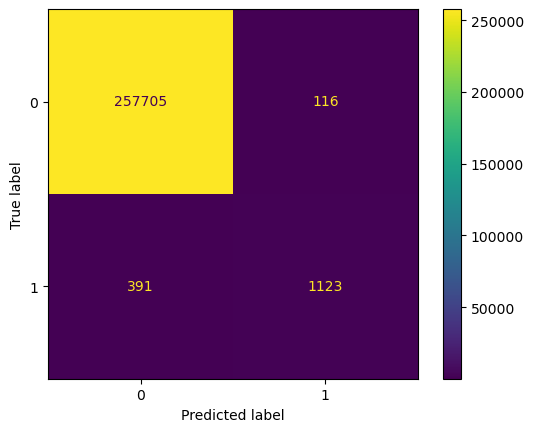

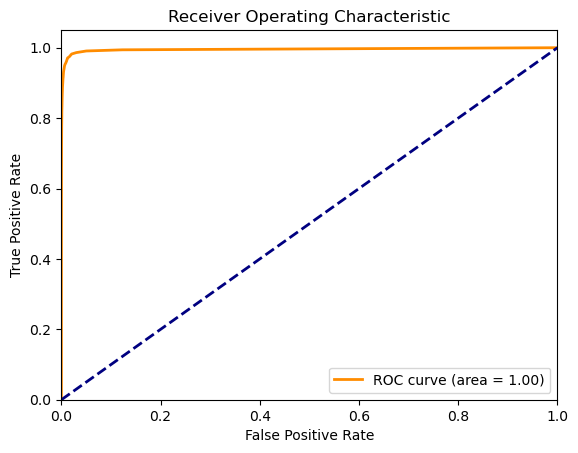

In [303]:
measure_metrics(y_test_unbalanced, y_pred_rf_smote_train, y_prob_rf_smote_train)

In [56]:
y_pred_rf_smote = rf_smote.predict(X_test_actual)
y_prob_rf_smote = rf_smote.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9576350637642406
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.02      0.16      0.03      2145

    accuracy                           0.96    555719
   macro avg       0.51      0.56      0.50    555719
weighted avg       0.99      0.96      0.97    555719

ROC AUC Score: 0.7709061745770479


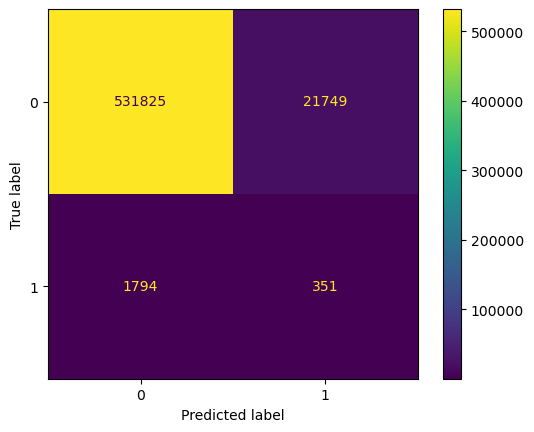

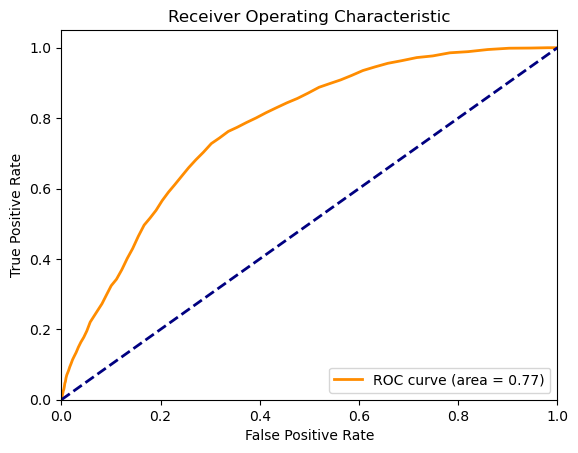

In [57]:
measure_metrics(y_test_actual, y_pred_rf_smote, y_prob_rf_smote)

#### Random Forest -

In [62]:
importances_rf = rf_smote.feature_importances_

# Select the top n features or based on a threshold
n_features = 22  # You can also use a threshold approach
indices = np.argsort(importances_rf)[::-1]
selected_features_rf = indices[:n_features]

In [63]:
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances_rf
})

In [64]:
feature_importance_rf.sort_values(by='Importance', ascending=True)

,Feature,Importance
8,year,0.002644
13,location_type,0.004335
15,le_gender,0.006331
14,location_cluster,0.006435
12,distance_to_merchant,0.014198
6,merch_lat,0.016693
7,merch_long,0.017880
9,month,0.017886
1,zip,0.018722
3,long,0.018846


### XGBoost

In [298]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier()
xgb_model.fit(X_train_smote, y_train_smote)

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/xgboost/data.py:575: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [299]:
y_pred_xgb_smote_train = xgb_model.predict(X_test_unbalanced)
y_prob_xgb_smote_train = xgb_model.predict_proba(X_test_unbalanced)[:, 1]

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/xgboost/data.py:575: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")
/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/xgboost/data.py:575: UserWarning: Sparse arrays from pandas are converted into dense.
  warnings.warn("Sparse arrays from pandas are converted into dense.")


Accuracy: 0.9983920411822547
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257821
           1       0.84      0.90      0.87      1514

    accuracy                           1.00    259335
   macro avg       0.92      0.95      0.93    259335
weighted avg       1.00      1.00      1.00    259335

ROC AUC Score: 0.9499445502769817


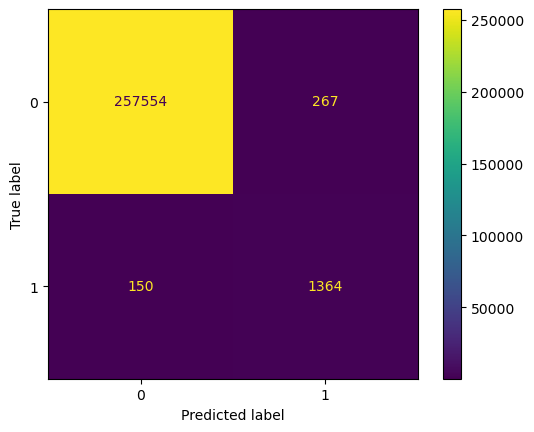

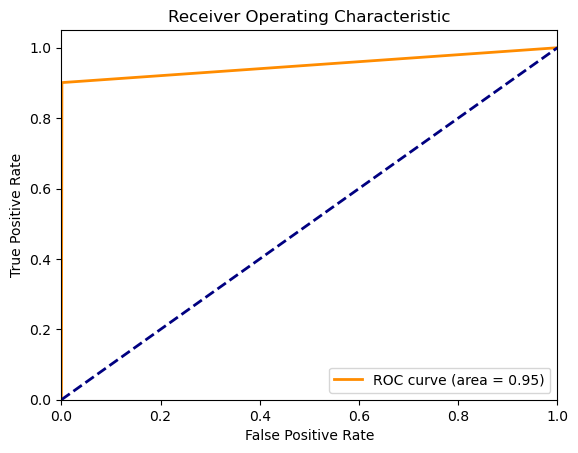

In [300]:
measure_metrics(y_test_unbalanced, y_pred_xgb_smote_train, y_pred_xgb_smote_train)

In [61]:
y_pred_xgb_smote_test = xgb_model.predict(X_test_actual)
y_prob_xgb_smote_test = xgb_model.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.6418711615042855
              precision    recall  f1-score   support

           0       1.00      0.64      0.78    553574
           1       0.01      0.74      0.02      2145

    accuracy                           0.64    555719
   macro avg       0.50      0.69      0.40    555719
weighted avg       0.99      0.64      0.78    555719

ROC AUC Score: 0.732544722333802


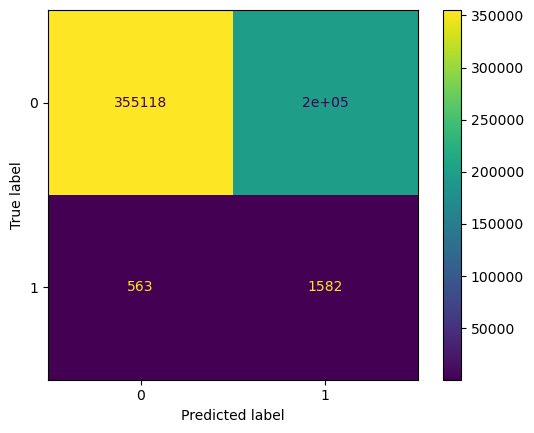

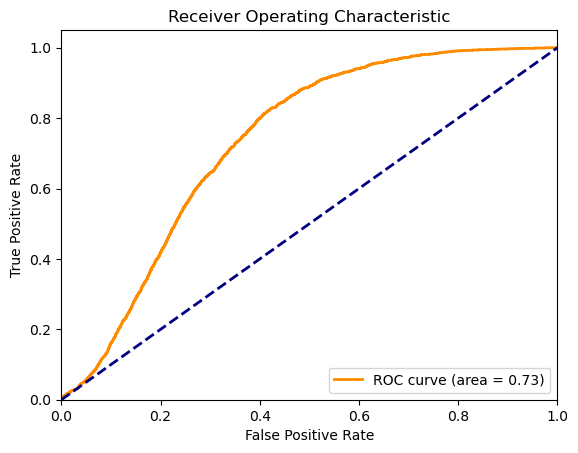

In [62]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test, y_prob_xgb_smote_test)

In [66]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 4, 5, 6, 7,8,9,10,11,12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.3],
    'min_child_weight': [1, 3, 5],
    'scale_pos_weight': [1, 10, 25, 50, 75, 99],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [0.1, 1.0, 10.0]
}


In [67]:
xgb_model_tune = xgb.XGBClassifier()

#### Scoring Precision

In [68]:
from sklearn.model_selection import RandomizedSearchCV
xgb_random_search_precision = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='precision', cv=2, verbose=2, 
                                   random_state=42)



In [70]:
xgb_random_search_precision.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.2s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.1s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.9s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.8s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.2s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.3s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   2.9s
[CV] END 

...

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   0.9s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.3s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.4s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.0s
[CV] END colsa

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200, 300],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='precision', verbose=2)

In [72]:
xgb_random_search_precision.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1,
 'reg_lambda': 10.0,
 'reg_alpha': 0.01,
 'n_estimators': 200,
 'min_child_weight': 3,
 'max_depth': 6,
 'learning_rate': 0.01,
 'gamma': 0.1,
 'colsample_bytree': 0.7}

In [73]:
y_pred_xgb_test_tuned_precision = xgb_random_search_precision.predict(X_test_actual)
y_prob_xgb_test_tuned_precision = xgb_random_search_precision.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9963308794552642
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.67      0.10      0.17      2145

    accuracy                           1.00    555719
   macro avg       0.83      0.55      0.58    555719
weighted avg       1.00      1.00      0.99    555719

ROC AUC Score: 0.9703839326838241


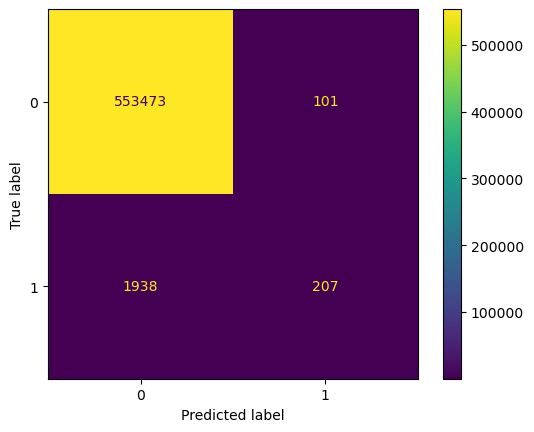

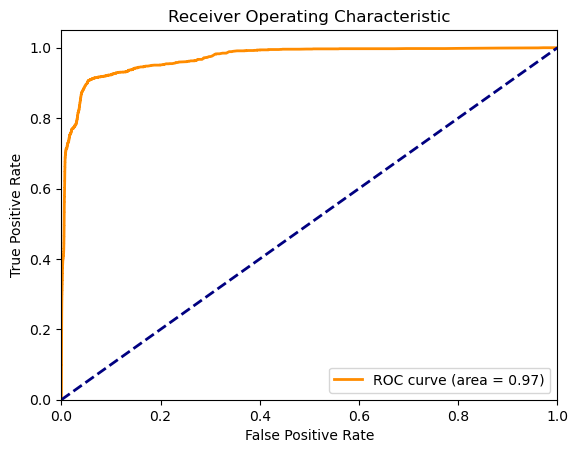

In [74]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_precision, y_prob_xgb_test_tuned_precision)

In [75]:
from sklearn.metrics import make_scorer, f1_score, precision_score, recall_score

In [76]:
scoring = {
    'precision': make_scorer(precision_score, average='binary'),
    'recall': make_scorer(recall_score, average='binary'),
    'f1': make_scorer(f1_score, average='binary')
}

In [78]:
xgb_random_search_all = RandomizedSearchCV(estimator=xgb_model_tune, 
                                       param_distributions=xgb_param_grid, 
                                       n_iter=100, 
                                       scoring=scoring, 
                                       refit='f1',  # Refit the model based on the F1 score
                                       cv=2, 
                                       verbose=2, 
                                       random_state=42)

In [79]:
xgb_random_search_all.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.3s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   4.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.4s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.6s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   1.5s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=11, min_child_weight=3, n_estimators=100, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.8; total time=   3.3s
[CV] END 

...

/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   1.0s


/Users/SandeshShrestha/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.8; total time=   1.0s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=5, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=1, subsample=0.7; total time=   4.1s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.1s
[CV] END colsample_bytree=0.9, gamma=0, learning_rate=0.2, max_depth=7, min_child_weight=3, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=1, subsample=0.7; total time=   2.1s
[CV] END colsa

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, refit='f1',
                   scoring={'f1': make_scorer(f1_score, response_method='predict', average=binary),
                            'precision': make_scorer(precision_score, response_method='predict', average=binary),
                            'recall': make_scorer(recall_score, response_method='predict', average=binary)},
                   verbose=2)

In [85]:
xgb_random_search_all.best_params_

{'subsample': 0.7,
 'scale_pos_weight': 1,
 'reg_lambda': 1.0,
 'reg_alpha': 0.01,
 'n_estimators': 50,
 'min_child_weight': 3,
 'max_depth': 8,
 'learning_rate': 0.05,
 'gamma': 0,
 'colsample_bytree': 0.8}

In [86]:
xgb_random_search_all.best_estimator_

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=8, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [87]:
xgb_random_search_all.best_score_

0.46053956203300916

In [89]:
xgb_random_search_all.cv_results_

{'mean_fit_time': array([0.90585983, 3.28067327, 3.788414  , 4.32089889, 3.73417354,
        0.72602773, 1.03080106, 4.14051485, 3.01312244, 4.29305148,
        1.08938992, 1.15235364, 2.40299153, 1.49256158, 1.28324986,
        1.71628046, 0.8856225 , 3.07963014, 4.06047642, 0.88016248,
        1.61417842, 3.42410445, 1.92351055, 1.09091341, 1.29107594,
        1.22345603, 1.5621165 , 1.12805843, 5.12647903, 2.93284309,
        3.81369555, 3.50359976, 3.71949649, 1.31194985, 0.95804465,
        0.85033405, 1.46200347, 3.5273515 , 2.15839803, 1.01717794,
        1.64860201, 4.39499211, 5.02219844, 0.80160844, 0.69980991,
        0.79424441, 1.27776945, 1.19369137, 1.47897732, 1.54595852,
        2.18845797, 3.38786709, 0.994313  , 1.66844189, 4.16744995,
        1.81133997, 3.31566083, 2.9447701 , 1.01872051, 3.77088094,
        6.37883055, 4.25877893, 0.96988714, 2.99907708, 1.67685103,
        1.91352904, 1.85251594, 3.28768706, 1.7487185 , 1.83445907,
        1.40158355, 1.02466059,

In [83]:
y_pred_xgb_test_tuned_all = xgb_random_search_all.predict(X_test_actual)
y_prob_xgb_test_tuned_all = xgb_random_search_all.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9927283393225713
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.17      0.23      0.20      2145

    accuracy                           0.99    555719
   macro avg       0.58      0.61      0.60    555719
weighted avg       0.99      0.99      0.99    555719

ROC AUC Score: 0.9654589886311391


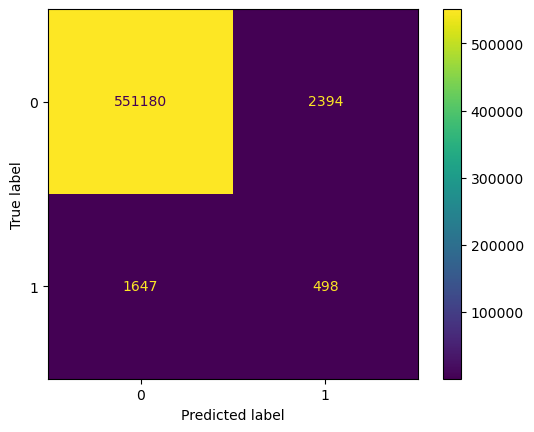

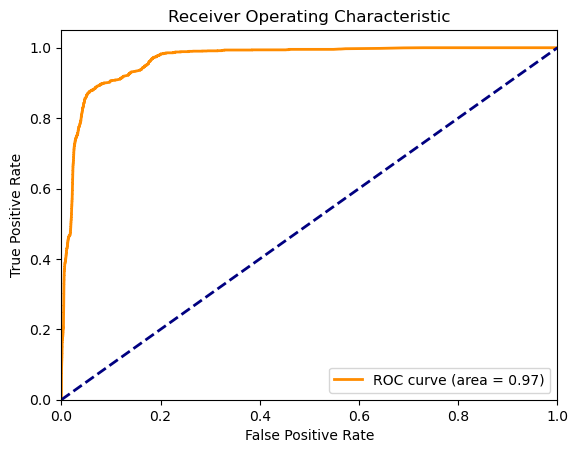

In [84]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_all, y_prob_xgb_test_tuned_all)

### Training in Test data

In [90]:
# Resample the dataset
X_train_smote_test, y_train_smote_test = smote.fit_resample(X_test_actual, y_test_actual)

In [91]:
xgb_random_search_test_recall = RandomizedSearchCV(estimator=xgb_model_tune, 
                                       param_distributions=xgb_param_grid, 
                                       n_iter=100, 
                                       scoring='recall', 
                                       cv=2, 
                                       verbose=2, 
                                       random_state=42)

In [92]:
xgb_random_search_test_recall.fit(X_train_smote_test, y_train_smote_test)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   1.1s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=5, min_child_weight=5, n_estimators=50, reg_alpha=0.1, reg_lambda=1.0, scale_pos_weight=25, subsample=0.9; total time=   0.9s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.9, gamma=0.3, learning_rate=0.1, max_depth=8, min_child_weight=1, n_estimators=200, reg_alpha=0.1, reg_lambda=10.0, scale_pos_weight=25, subsample=0.8; total time=   3.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=10, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=0.1, 

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=75, subsample=0.9; total time=   3.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=75, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.7; total time=   2.0s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=75, subsample=0.7; total time=   1.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.05, max_depth=8, min_child_weight=1, n_estimators=50, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=50, subsample=0.7; total time=   1.1s
[CV] END col

[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=99, subsample=0.9; total time=   4.8s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.01, max_depth=8, min_child_weight=5, n_estimators=300, reg_alpha=0, reg_lambda=0.1, scale_pos_weight=99, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=3, min_child_weight=5, n_estimators=50, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=3, n_estimators=50, reg_alpha=0.1, reg_lambda=0.1, scale_pos_weight=1, subsample=0.7; total time=   0.9s
[CV] END colsampl

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=0.1, scale_pos_weight=25, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=0.1, scale_pos_weight=25, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=25, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=5, n_estimators=100, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=25, subsample=0.7; total time=   1.7s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.2, max_depth=3, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=10.0, scale_pos_weight=99, subsample=0.7; total time=   2.0s
[C

[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=11, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   6.0s
[CV] END colsample_bytree=0.9, gamma=0.1, learning_rate=0.05, max_depth=11, min_child_weight=1, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=25, subsample=0.7; total time=   4.0s
[CV] END colsample_bytree=0.7, gamma=0.3, learning_rate=0.2, max_depth=6, min_child_weight=3, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=25, subsample=0.7; total time=   3.8s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.05, max_depth=4, min_child_weight=5, n_estimators=300, reg_alpha=0.01, reg_lambda=1.0, scale_pos_weight=50, subsample=0.7; total time=   3.2s
[C

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                   param_distributions={'colsample_bytree': [0.7, 0.8, 0.9],
                                        'gamma': [0, 0.1, 0.3],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10,
                                                      11, 12],
                                        'min_child_weight': [1, 3, 5],
                                        'n_estimators': [50, 100, 200, 300],
                                        'reg_alpha': [0, 0.01, 0.1],
                                        'reg_lambda': [0.1, 1.0, 10.0],
                                        'scale_pos_weight': [1, 10, 25, 50, 75,
                                                             99],
                                        'subsample': [0.7, 0.8, 0.9]},
                   random_state=42, scoring='recall', verbose=2)

In [93]:
y_pred_xgb_test_tuned_recall_test = xgb_random_search_test_recall.predict(X)
y_prob_xgb_test_tuned_recall_test = xgb_random_search_test_recall.predict_proba(X)[:, 1]

xgb_random_search_test_recall.best_params_

In [96]:
xgb_random_search_test_recall.best_score_

1.0

Accuracy: 0.005844178379316329
              precision    recall  f1-score   support

           0       1.00      0.00      0.00   1289169
           1       0.01      1.00      0.01      7506

    accuracy                           0.01   1296675
   macro avg       0.50      0.50      0.01   1296675
weighted avg       0.99      0.01      0.00   1296675

ROC AUC Score: 0.9011013130399731


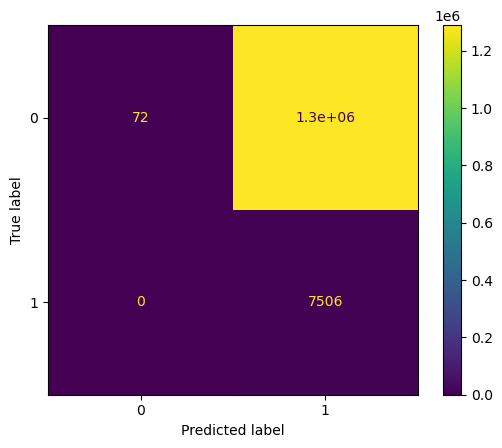

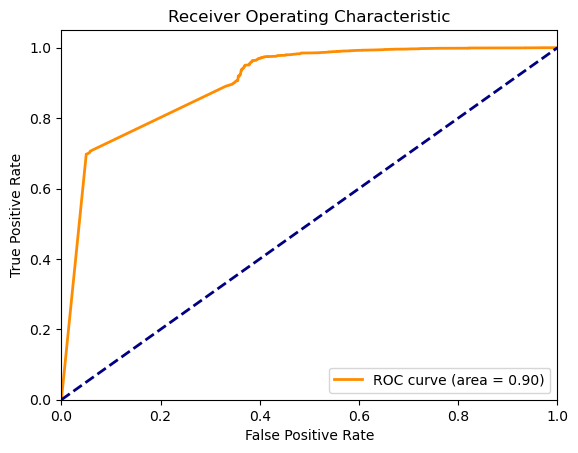

In [94]:
measure_metrics(y, y_pred_xgb_test_tuned_recall_test, y_prob_xgb_test_tuned_recall_test)

In [117]:
xgb_tuned_on_test_data = xgb.XGBClassifier(
    subsample=1,
    reg_lambda=0.1,
    reg_alpha=0.01,
    n_estimators=50,
    min_child_weight=5,
    max_depth=1,
    learning_rate=0.01,
    gamma=0,
    colsample_bytree=0.8
)


In [118]:
xgb_tuned_on_test_data.fit(X_train_smote, y_train_smote)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=1, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=50, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [119]:
y_pred_xgb_tuned_on_test_data = xgb_tuned_on_test_data.predict(X_test_actual)
y_prob_xgb_tuned_on_test_data = xgb_tuned_on_test_data.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9564132232297258
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.75      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719

ROC AUC Score: 0.9450760021193242


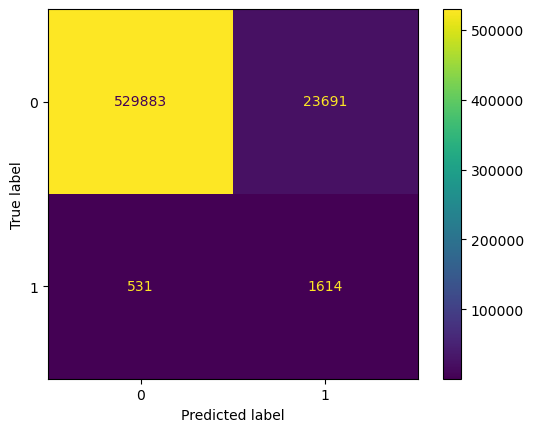

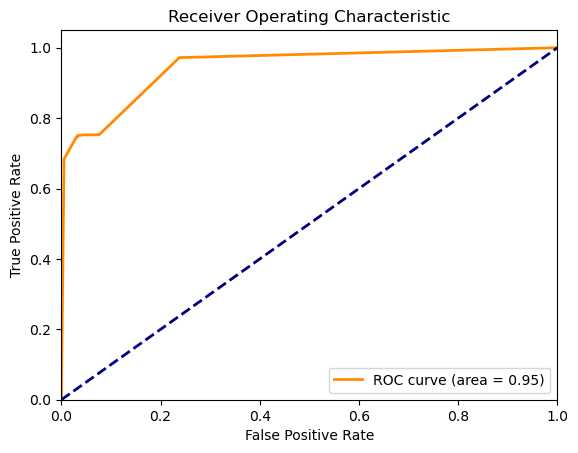

In [120]:
measure_metrics(y_test_actual, y_pred_xgb_tuned_on_test_data, y_prob_xgb_tuned_on_test_data)

#### Scoring in Recall (balanced)

In [90]:
xgb_random_search_balanced_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [85]:
xgb_random_search_recall.fit(X,y)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.6s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.6s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   2.7s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   5.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   4.6s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   5.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.6s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=   5.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.4s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=   8.6s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   6.0s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   5.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=   7.4s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   2.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.1s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.3s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   4.7s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   3.2s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [92]:
y_pred_xgb_test_tuned_recall = xgb_random_search_recall.predict(X_test_actual)
y_prob_xgb_test_tuned_recall = xgb_random_search_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


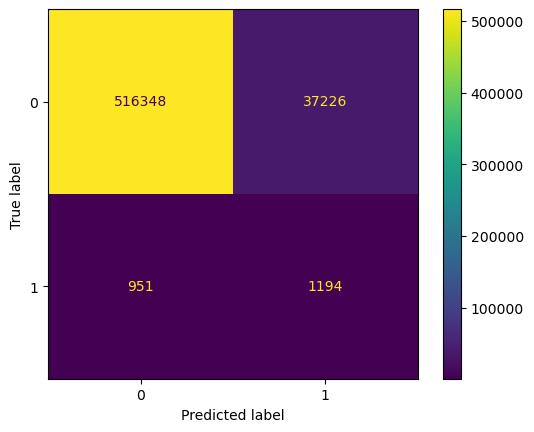

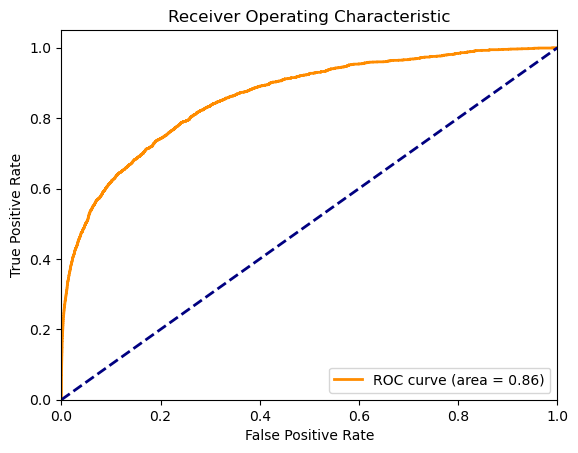

In [93]:
measure_metrics(y_test_actual, y_pred_xgb_test_tuned_recall, y_prob_xgb_test_tuned_recall)

In [ ]:
#### Scoring in 

#### Scoring in Recall (balanced)

In [84]:
xgb_random_search_smote_recall = RandomizedSearchCV(estimator=xgb_model_tune, param_distributions=xgb_param_grid, 
                                   n_iter=100, scoring='recall', cv=2, verbose=2, 
                                   random_state=42)

In [91]:
xgb_random_search_recall.fit(X_train_smote, y_train_smote)

Fitting 2 folds for each of 100 candidates, totalling 200 fits
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.1, max_depth=3, n_estimators=500, reg_alpha=0.1, reg_lambda=1.0, subsample=0.9; total time=   6.4s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   4.1s
[CV] END colsample_bytree=0.7, gamma=0.2, learning_rate=0.15, max_depth=10, n_estimators=100, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   3.9s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   8.0s
[CV] END colsample_bytree=0.7, gamma=0.1, learning_rate=0.3, max_depth=4, n_estimators=500, reg_alpha=0, reg_lambda=0.5, subsample=0.8; total time=   

[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.5s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.1, max_depth=4, n_estimators=400, reg_alpha=0, reg_lambda=0, subsample=0.7; total time=   6.9s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.0s
[CV] END colsample_bytree=0.8, gamma=0.3, learning_rate=0.3, max_depth=7, n_estimators=400, reg_alpha=0, reg_lambda=1.0, subsample=0.6; total time=  10.1s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.2s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.1, max_depth=5, n_estimators=200, reg_alpha=1.0, reg_lambda=1.0, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.8, gamma=0.2, learning_rate=0.05, max_depth=8, n_e

[CV] END colsample_bytree=0.9, gamma=0.2, learning_rate=0.01, max_depth=9, n_estimators=200, reg_alpha=1.0, reg_lambda=0.1, subsample=0.8; total time=   7.0s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  16.5s
[CV] END colsample_bytree=0.6, gamma=0.1, learning_rate=0.15, max_depth=9, n_estimators=500, reg_alpha=0.1, reg_lambda=0.5, subsample=0.7; total time=  15.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.2, max_depth=4, n_estimators=500, reg_alpha=0.5, reg_lambda=0, subsample=0.6; total time=   8.1s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05, max_depth=6, n_estimators=500, reg_alpha=0, reg_lambda=1.0, subsample=0.9; total time=  10.3s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.05

[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   3.9s
[CV] END colsample_bytree=0.8, gamma=0.4, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.1, reg_lambda=0, subsample=0.9; total time=   4.2s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.8s
[CV] END colsample_bytree=0.9, gamma=0.4, learning_rate=0.1, max_depth=6, n_estimators=400, reg_alpha=0, reg_lambda=0.5, subsample=1.0; total time=   7.6s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.3s
[CV] END colsample_bytree=0.7, gamma=0, learning_rate=0.15, max_depth=5, n_estimators=200, reg_alpha=0.5, reg_lambda=0.5, subsample=0.6; total time=   4.1s
[CV] END colsample_bytree=0.6, gamma=0.4, learning_rate=0.05, max_

RandomizedSearchCV(cv=2,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           gamma=None, grow_policy=None,
                                           importance_type=None,
                                           interaction_constraints=None,
                                           learning_rate...
                                           random_state=None, ...),
                   n_iter=100,
                   param_distributions={'colsample_bytree': [0.6, 0.7, 0.8, 0.9,
                                                             1.0],
                                        'gamma': [0, 0.1, 0.2, 0.3, 0.4],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.15,
                                                          0.2, 0.3],
                                        'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500],
                                        'reg_alpha': [0, 0.1, 0.5, 1.0],
                                        'reg_lambda': [0, 0.1, 0.5, 1.0],
                                        'subsample': [0.6, 0.7, 0.8, 0.9, 1.0]},
                   random_state=42, scoring='recall', verbose=2)

In [98]:
y_pred_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict(X_test_actual)
y_prob_xgb_smote_test_tuned_recall = xgb_random_search_smote_recall.predict_proba(X_test_actual)[:, 1]

Accuracy: 0.9313016110660244
              precision    recall  f1-score   support

           0       1.00      0.93      0.96    553574
           1       0.03      0.56      0.06      2145

    accuracy                           0.93    555719
   macro avg       0.51      0.74      0.51    555719
weighted avg       0.99      0.93      0.96    555719

ROC AUC Score: 0.8591523382664223


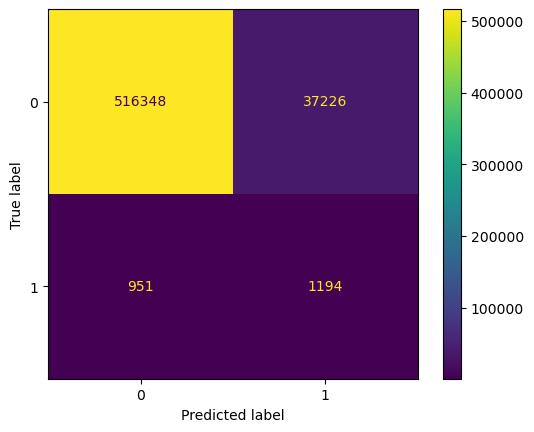

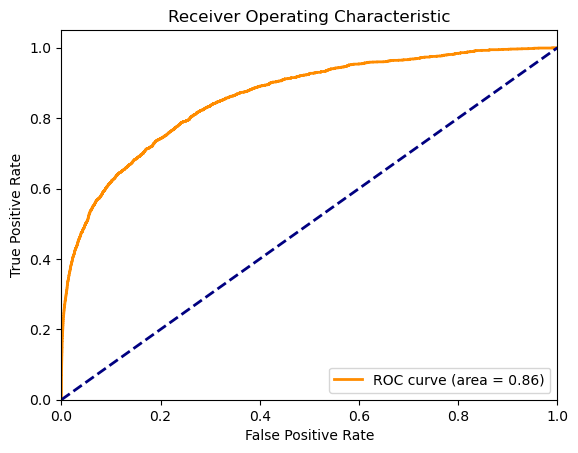

In [99]:
measure_metrics(y_test_actual, y_pred_xgb_smote_test_tuned_recall, y_prob_xgb_smote_test_tuned_recall)